# 使用 PyTorch 多层感知机学习 x 与 y 的函数关系

- **功能**：读取 `Data.root` 中 `tree` TTree 的 `x`、`y`、`noise` 分支，训练 `1→8→8→1` 回归网络学习 x 与 y 的函数关系，并绘制损失、拟合曲线以及 `[-10,10]` 外推对比。
- **方法**：使用 `uproot` 和 NumPy 读取数据，按 80%/20% 随机划分训练集与测试集；仅用训练集统计量标准化 x 和 y，再将数据和使用 Tanh 的 PyTorch `1→8→8→1` 网络放到 Apple Metal `mps` 设备上训练；训练后在 `[-10,10]` 采样并与理论函数比较。
- **注意事项**：需安装 `uproot`、`numpy`、`torch` 和 `matplotlib`，并从 `1DFunctionFit` 目录运行；代码严格要求 PyTorch MPS GPU，不可用时会直接报错；模型只在 `[-5,5]` 训练，该区间以外的预测不受训练数据约束。

In [1]:
import numpy as np
import uproot

with uproot.open("Data.root") as root_file:
    tree = root_file["tree"] #读取ROOT文件的树 TTree *tree = (TTree*)file->Get("tree");
    branches = tree.arrays(["x", "y", "noise"], library="np") #读取root文件中的三个branch，并转化为np结构的数据

data = np.column_stack((branches["x"], branches["y"], branches["noise"])) #column_stack 的意思是把三个branch的数据按列排布

In [2]:
import torch

if not torch.backends.mps.is_available():
    raise RuntimeError("PyTorch MPS GPU 不可用，请检查 Apple Silicon/macOS 和 PyTorch 安装")

device = torch.device("mps")

# 把 NumPy ndarray 直接转为 MPS GPU 上的 PyTorch Tensor
data_tensor = torch.tensor(data, dtype=torch.float32, device=device)

print("shape =", data_tensor.shape)
print("dtype =", data_tensor.dtype)
print("device =", data_tensor.device)

shape = torch.Size([501, 3])
dtype = torch.float32
device = mps:0


## 准备训练数据和定义 1→8→8→1 网络

网络完全使用 PyTorch 已封装的组件，两个隐藏层均含 8 个神经元并使用 Tanh 激活，输出层用线性输出进行回归。

In [ ]:
import matplotlib.pyplot as plt
import torch.nn as nn

torch.manual_seed(42)

X = data_tensor[:, 0:1] #取data_tensor第0列到第1列之前，也就是只取第0列
Y = data_tensor[:, 1:2] #取data_tensor第1列到第2列之前，也就是只取第1列

# 固定随机种子后划分 80% 训练集和 20% 测试集
indices = torch.randperm(X.shape[0], device=device)
train_size = int(0.8 * X.shape[0]) #80%的训练值
train_indices = indices[:train_size]
test_indices = indices[train_size:]
x_train, y_train = X[train_indices], Y[train_indices] #取出训练集作为网络的输入
x_test, y_test = X[test_indices], Y[test_indices] #取出测试集作为网络的输入

# 只用训练集计算标准化参数，避免测试集信息泄漏（进行数据的归一化，避免出现不同尺度的数据）
x_mean, x_std = x_train.mean(), x_train.std()
y_mean, y_std = y_train.mean(), y_train.std()
x_train_scaled = (x_train - x_mean) / x_std
y_train_scaled = (y_train - y_mean) / y_std
x_test_scaled = (x_test - x_mean) / x_std

#ReLU是分段线性的，会导致曲线不平滑

# model = nn.Sequential(
#     nn.Linear(1, 8),
#     nn.ReLU(),
#     nn.Linear(8, 8),
#     nn.ReLU(),
#     nn.Linear(8, 1),
# ).to(device)

#Tanh是连续的，预测的曲线可以是平滑的

model = nn.Sequential(
    nn.Linear(1, 8),
    nn.Tanh(),
    nn.Linear(8, 8),
    nn.Tanh(),
    nn.Linear(8, 1),
).to(device)

print(f"train samples = {len(train_indices)}, test samples = {len(test_indices)}")
print(model)

train samples = 400, test samples = 101
Sequential(
  (0): Linear(in_features=1, out_features=8, bias=True)
  (1): Tanh()
  (2): Linear(in_features=8, out_features=8, bias=True)
  (3): Tanh()
  (4): Linear(in_features=8, out_features=1, bias=True)
)


In [ ]:
loss_function = nn.MSELoss() #MSE是均方误差
optimizer = torch.optim.Adam(model.parameters(), lr=0.01) #Adam 优化器
epoch_count = 3000
loss_history = []

model.train() #把模型切换为训练模式
for epoch in range(epoch_count):
    prediction_scaled = model(x_train_scaled)
    loss = loss_function(prediction_scaled, y_train_scaled)

    optimizer.zero_grad() #清除梯度
    loss.backward() #反向传播
    optimizer.step() #更新网络参数

    loss_history.append(loss.item())
    if (epoch + 1) % 500 == 0:
        print(f"epoch {epoch + 1:4d}/{epoch_count}, scaled MSE = {loss.item():.6f}")

epoch  500/3000, scaled MSE = 0.016834


epoch 1000/3000, scaled MSE = 0.016130


epoch 1500/3000, scaled MSE = 0.015987


epoch 2000/3000, scaled MSE = 0.015928


epoch 2500/3000, scaled MSE = 0.015906


epoch 3000/3000, scaled MSE = 0.015892


test MSE  = 0.964193
test RMSE = 0.981933
test MAE  = 0.793656


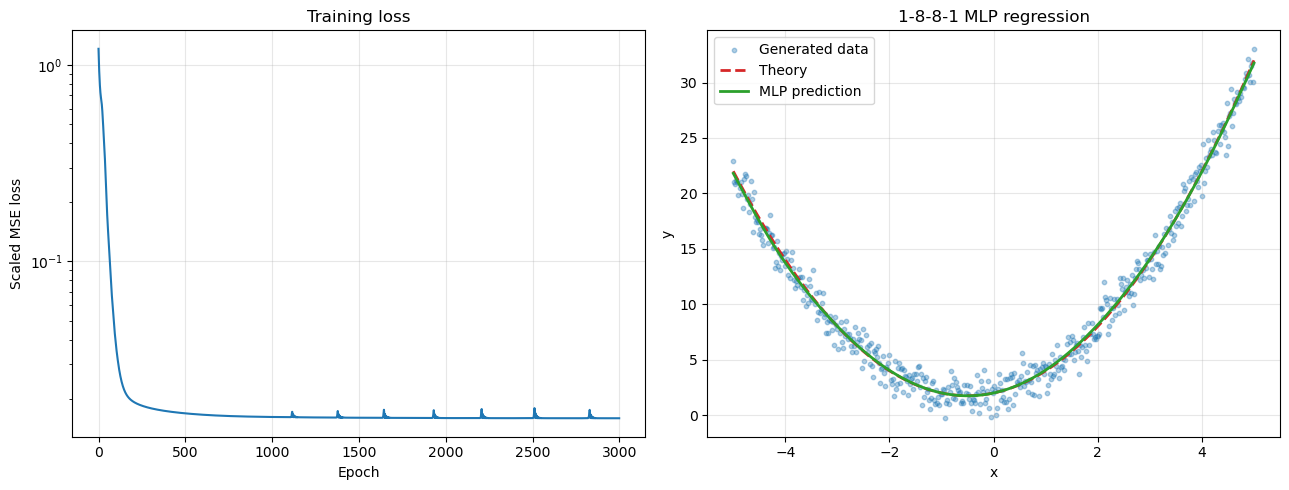

In [ ]:
model.eval() #把神经网络切换到评估模式
with torch.no_grad(): #用已经训练好的模型进行预测，不需要计算梯度
    y_test_prediction = model(x_test_scaled) * y_std + y_mean #数据反标准化
    test_mse = nn.functional.mse_loss(y_test_prediction, y_test).item()
    test_mae = nn.functional.l1_loss(y_test_prediction, y_test).item()

    x_curve = torch.linspace(X.min().item(), X.max().item(), 1000, device=device).reshape(-1, 1)
    x_curve_scaled = (x_curve - x_mean) / x_std
    y_curve_prediction = model(x_curve_scaled) * y_std + y_mean
    y_curve_theory = x_curve**2 + x_curve + 2.0

print(f"test MSE  = {test_mse:.6f}")
print(f"test RMSE = {test_mse**0.5:.6f}")
print(f"test MAE  = {test_mae:.6f}")

figure, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(loss_history, color="tab:blue")
axes[0].set_yscale("log")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Scaled MSE loss")
axes[0].set_title("Training loss")
axes[0].grid(alpha=0.3)

axes[1].scatter(X.cpu().numpy(), Y.cpu().numpy(), s=10, alpha=0.35, label="Generated data")
axes[1].plot(x_curve.cpu().numpy(), y_curve_theory.cpu().numpy(), "--", color="tab:red", linewidth=2, label="Theory")
axes[1].plot(x_curve.cpu().numpy(), y_curve_prediction.cpu().numpy(), color="tab:green", linewidth=2, label="MLP prediction")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].set_title("1-8-8-1 MLP regression")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

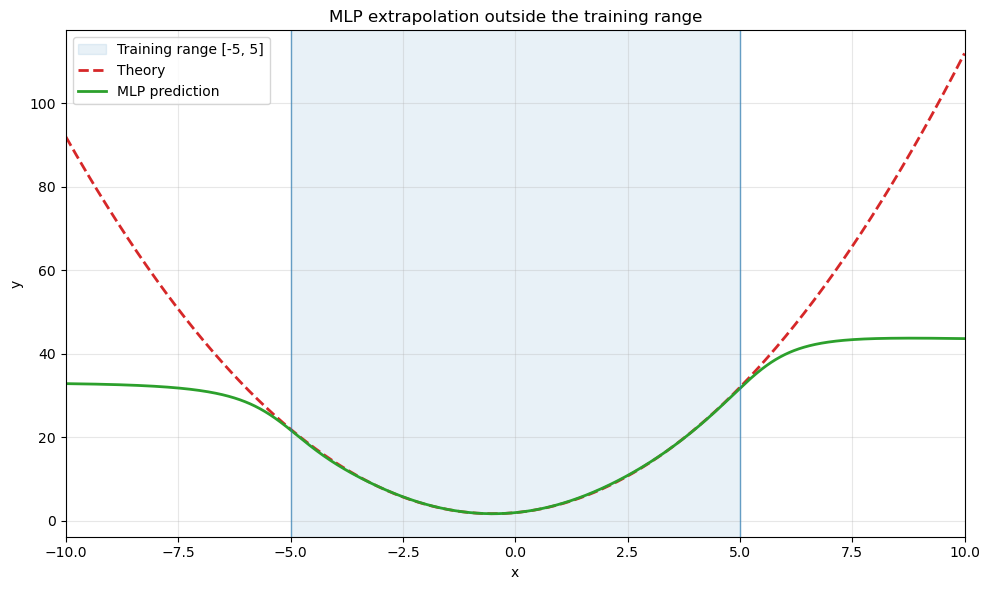

In [6]:
# 复用已训练的模型，比较 [-10, 10] 上的外推预测与理论曲线
model.eval()
with torch.no_grad():
    x_extrapolation = torch.linspace(-10.0, 10.0, 2000, device=device).reshape(-1, 1)
    x_extrapolation_scaled = (x_extrapolation - x_mean) / x_std
    y_extrapolation_prediction = model(x_extrapolation_scaled) * y_std + y_mean
    y_extrapolation_theory = x_extrapolation**2 + x_extrapolation + 2.0

plt.figure(figsize=(10, 6))
plt.axvspan(-5.0, 5.0, color="tab:blue", alpha=0.10, label="Training range [-5, 5]")
plt.plot(x_extrapolation.cpu().numpy(), y_extrapolation_theory.cpu().numpy(), "--", color="tab:red", linewidth=2, label="Theory")
plt.plot(x_extrapolation.cpu().numpy(), y_extrapolation_prediction.cpu().numpy(), color="tab:green", linewidth=2, label="MLP prediction")
plt.axvline(-5.0, color="tab:blue", linewidth=1, alpha=0.6)
plt.axvline(5.0, color="tab:blue", linewidth=1, alpha=0.6)
plt.xlim(-10.0, 10.0)
plt.xlabel("x")
plt.ylabel("y")
plt.title("MLP extrapolation outside the training range")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()